# AI For Fraud Detection

### This project develops an AI-powered fraud detection system that uses machine learning to identify suspicious patterns and anomalies in financial transactions.

### Through comprehensive Exploratory Data Analysis, feature engineering, and robust preprocessing, hidden fraud patterns are uncovered from highly imbalanced transaction data.
### Three powerful models like Scikit-learn Logistic Regression, Random Forest, and Gradient Boosting are trained, evaluated, and compared using industry-standard performance metrics.
### By analyzing transaction behavior in real time, the system helps improve financial security, reduce risk, and prevent fraudulent activities with high accuracy.

#### STEP 1: IMPORT LIBRARIES

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, roc_curve, precision_recall_curve, 
                             f1_score, accuracy_score, auc)
import warnings
warnings.filterwarnings('ignore')
 
print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


####  STEP 2: LOAD AND EXPLORE DATA

In [4]:
df = pd.read_csv('/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv')
 
print("\n" + "="*60)
print("DATASET OVERVIEW")
print("="*60)
print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())
print(f"\nData types:")
print(df.dtypes)
print(f"\nMissing values:")
print(df.isnull().sum())
print(f"\nBasic statistics:")
print(df.describe())
 


DATASET OVERVIEW
Dataset shape: (284807, 31)

First few rows:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.

#### STEP 3: EXPLORATORY DATA ANALYSIS (EDA)


FRAUD DISTRIBUTION ANALYSIS

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud percentage: 0.17%


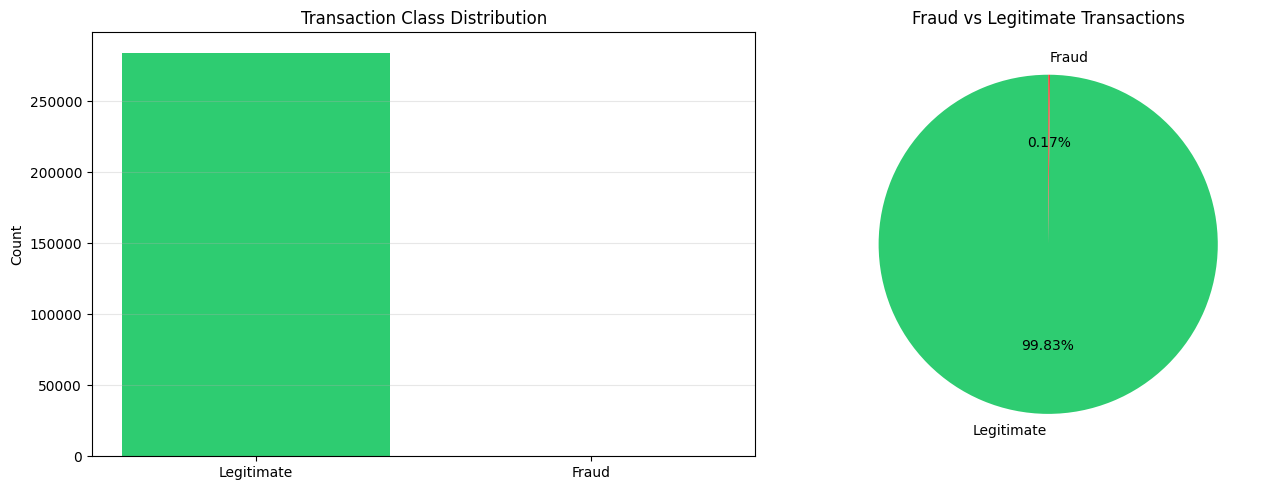

In [5]:
print("\n" + "="*60)
print("FRAUD DISTRIBUTION ANALYSIS")
print("="*60)
 
# Check class distribution
fraud_count = df['Class'].value_counts()
print(f"\nClass distribution:")
print(fraud_count)
print(f"\nFraud percentage: {(fraud_count[1] / len(df)) * 100:.2f}%")
 
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# Count plot
fraud_labels = ['Legitimate', 'Fraud']
axes[0].bar(fraud_labels, fraud_count.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_ylabel('Count')
axes[0].set_title('Transaction Class Distribution')
axes[0].grid(axis='y', alpha=0.3)
 
# Pie chart
axes[1].pie(fraud_count.values, labels=fraud_labels, autopct='%1.2f%%', 
            colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Fraud vs Legitimate Transactions')
 
plt.tight_layout()
plt.show()

#### STEP 4: ANALYZE FEATURES


FEATURE ANALYSIS

Amount statistics by Class:
          count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      284315.0   88.291022  250.105092  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.211321  256.683288  0.0  1.00   9.25  105.89   2125.87


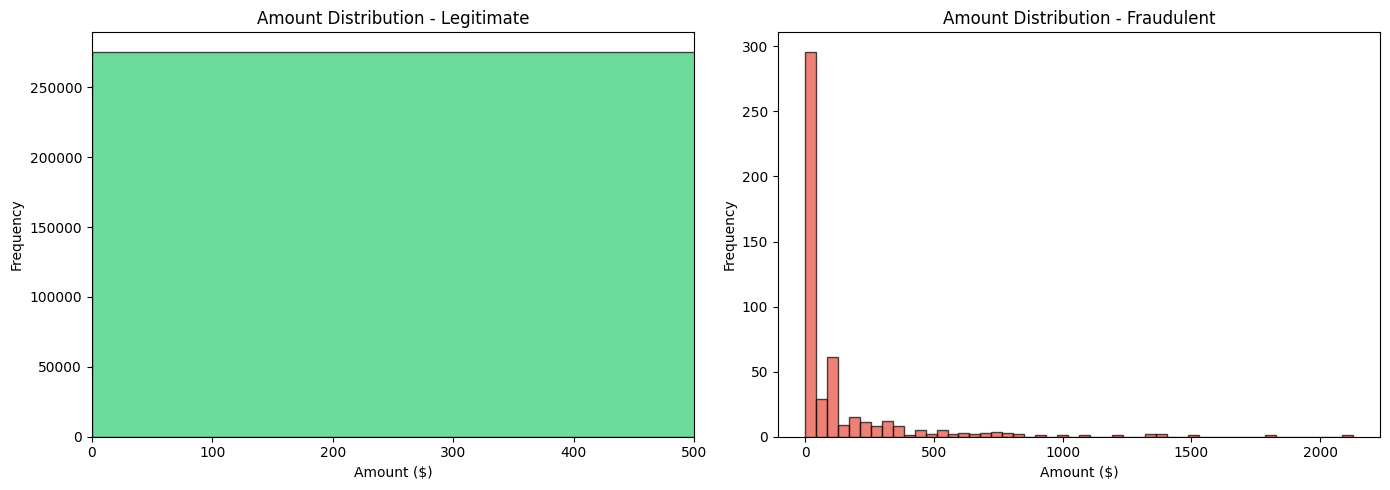


Top 10 features correlated with fraud:
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
Name: Class, dtype: float64


In [6]:
print("\n" + "="*60)
print("FEATURE ANALYSIS")
print("="*60)
 
# Amount statistics by class
print("\nAmount statistics by Class:")
print(df.groupby('Class')['Amount'].describe())
 
# Visualize Amount distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# Legitimate transactions
axes[0].hist(df[df['Class'] == 0]['Amount'], bins=50, color='#2ecc71', alpha=0.7, edgecolor='black')
axes[0].set_title('Amount Distribution - Legitimate')
axes[0].set_xlabel('Amount ($)')
axes[0].set_ylabel('Frequency')
axes[0].set_xlim(0, 500)
 
# Fraudulent transactions
axes[1].hist(df[df['Class'] == 1]['Amount'], bins=50, color='#e74c3c', alpha=0.7, edgecolor='black')
axes[1].set_title('Amount Distribution - Fraudulent')
axes[1].set_xlabel('Amount ($)')
axes[1].set_ylabel('Frequency')
 
plt.tight_layout()
plt.show()
 
# Correlation analysis
print("\nTop 10 features correlated with fraud:")
correlation_with_fraud = df.corr()['Class'].sort_values(ascending=False)
print(correlation_with_fraud.head(11)[1:])  # Skip Class itself

####  STEP 5: DATA PREPROCESSING

In [7]:
print("\n" + "="*60)
print("DATA PREPROCESSING")
print("="*60)
 
# Create a copy for preprocessing
df_processed = df.copy()
 
# Scale the 'Amount' feature (Time is already scaled)
scaler = RobustScaler()
df_processed['Amount'] = scaler.fit_transform(df_processed[['Amount']])
 
# Separate features and target
X = df_processed.drop('Class', axis=1)
y = df_processed['Class']
 
print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")
 
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
 
print(f"\nTraining set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")
print(f"Training fraud ratio: {(y_train.sum() / len(y_train)) * 100:.2f}%")
print(f"Testing fraud ratio: {(y_test.sum() / len(y_test)) * 100:.2f}%")
 
# Scale features for algorithms that benefit from scaling
scaler_features = StandardScaler()
X_train_scaled = scaler_features.fit_transform(X_train)
X_test_scaled = scaler_features.transform(X_test)
 
print("\n✓ Data preprocessing completed!")


DATA PREPROCESSING

Features shape: (284807, 30)
Target shape: (284807,)

Training set size: (199364, 30)
Testing set size: (85443, 30)
Training fraud ratio: 0.17%
Testing fraud ratio: 0.17%

✓ Data preprocessing completed!


#### STEP 6: BUILD LOGISTIC REGRESSION MODEL

In [8]:
print("\n" + "="*60)
print("MODEL 1: LOGISTIC REGRESSION")
print("="*60)
 
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
 
# Predictions
y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]
 
# Evaluation
print(f"\nAccuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {(y_test[y_pred_lr == 1].sum() / (y_pred_lr == 1).sum()):.4f}" if (y_pred_lr == 1).sum() > 0 else "N/A")
print(f"F1-Score: {f1_score(y_test, y_pred_lr):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_prob_lr):.4f}")
 
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['Legitimate', 'Fraud']))


MODEL 1: LOGISTIC REGRESSION

Accuracy: 0.9991
Precision: 0.8505
F1-Score: 0.7137
ROC-AUC: 0.9567

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     85295
       Fraud       0.85      0.61      0.71       148

    accuracy                           1.00     85443
   macro avg       0.92      0.81      0.86     85443
weighted avg       1.00      1.00      1.00     85443



#### STEP 7: BUILD RANDOM FOREST MODEL

In [9]:
print("\n" + "="*60)
print("MODEL 2: RANDOM FOREST")
print("="*60)
 
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, max_depth=15)
rf_model.fit(X_train, y_train)
 
# Predictions
y_pred_rf = rf_model.predict(X_test)
y_pred_prob_rf = rf_model.predict_proba(X_test)[:, 1]
 
# Evaluation
print(f"\nAccuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {(y_test[y_pred_rf == 1].sum() / (y_pred_rf == 1).sum()):.4f}" if (y_pred_rf == 1).sum() > 0 else "N/A")
print(f"F1-Score: {f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_prob_rf):.4f}")
 
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Legitimate', 'Fraud']))
 
# Feature importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)
 
print("\nTop 10 Important Features:")
print(feature_importance.head(10))


MODEL 2: RANDOM FOREST

Accuracy: 0.9995
Precision: 0.9496
F1-Score: 0.8464
ROC-AUC: 0.9655

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     85295
       Fraud       0.95      0.76      0.85       148

    accuracy                           1.00     85443
   macro avg       0.97      0.88      0.92     85443
weighted avg       1.00      1.00      1.00     85443


Top 10 Important Features:
   Feature  Importance
17     V17    0.175353
12     V12    0.142486
14     V14    0.132601
10     V10    0.085060
16     V16    0.071712
11     V11    0.056042
9       V9    0.033682
18     V18    0.030674
4       V4    0.029493
7       V7    0.028326


#### STEP 8: BUILD GRADIENT BOOSTING MODEL

In [11]:
print("\n" + "="*60)
print("MODEL 3: GRADIENT BOOSTING")
print("="*60)
 
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42, max_depth=5)
gb_model.fit(X_train, y_train)
 
# Predictions
y_pred_gb = gb_model.predict(X_test)
y_pred_prob_gb = gb_model.predict_proba(X_test)[:, 1]
 
# Evaluation
print(f"\nAccuracy: {accuracy_score(y_test, y_pred_gb):.4f}")
print(f"Precision: {(y_test[y_pred_gb == 1].sum() / (y_pred_gb == 1).sum()):.4f}" if (y_pred_gb == 1).sum() > 0 else "N/A")
print(f"F1-Score: {f1_score(y_test, y_pred_gb):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_prob_gb):.4f}")
 
print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb, target_names=['Legitimate', 'Fraud']))


MODEL 3: GRADIENT BOOSTING

Accuracy: 0.9991
Precision: 0.8273
F1-Score: 0.7054
ROC-AUC: 0.7488

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     85295
       Fraud       0.83      0.61      0.71       148

    accuracy                           1.00     85443
   macro avg       0.91      0.81      0.85     85443
weighted avg       1.00      1.00      1.00     85443



#### STEP 9: MODEL COMPARISON

In [12]:
print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)
 
models_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_gb)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_pred_prob_lr),
        roc_auc_score(y_test, y_pred_prob_rf),
        roc_auc_score(y_test, y_pred_prob_gb)
    ]
})
 
print("\n")
print(models_comparison.to_string(index=False))


MODEL COMPARISON


              Model  Accuracy  F1-Score  ROC-AUC
Logistic Regression  0.999146  0.713725 0.956719
      Random Forest  0.999520  0.846442 0.965543
  Gradient Boosting  0.999111  0.705426 0.748792


#### STEP 10: VISUALIZATIONS


GENERATING VISUALIZATIONS


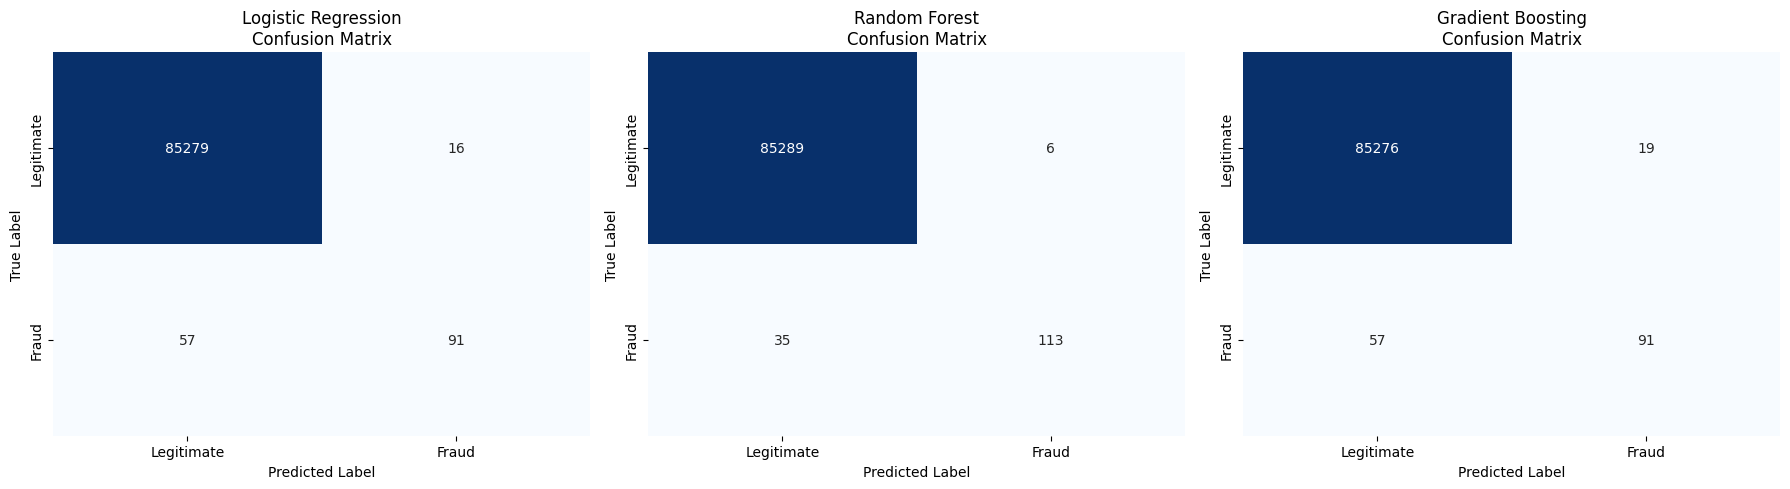

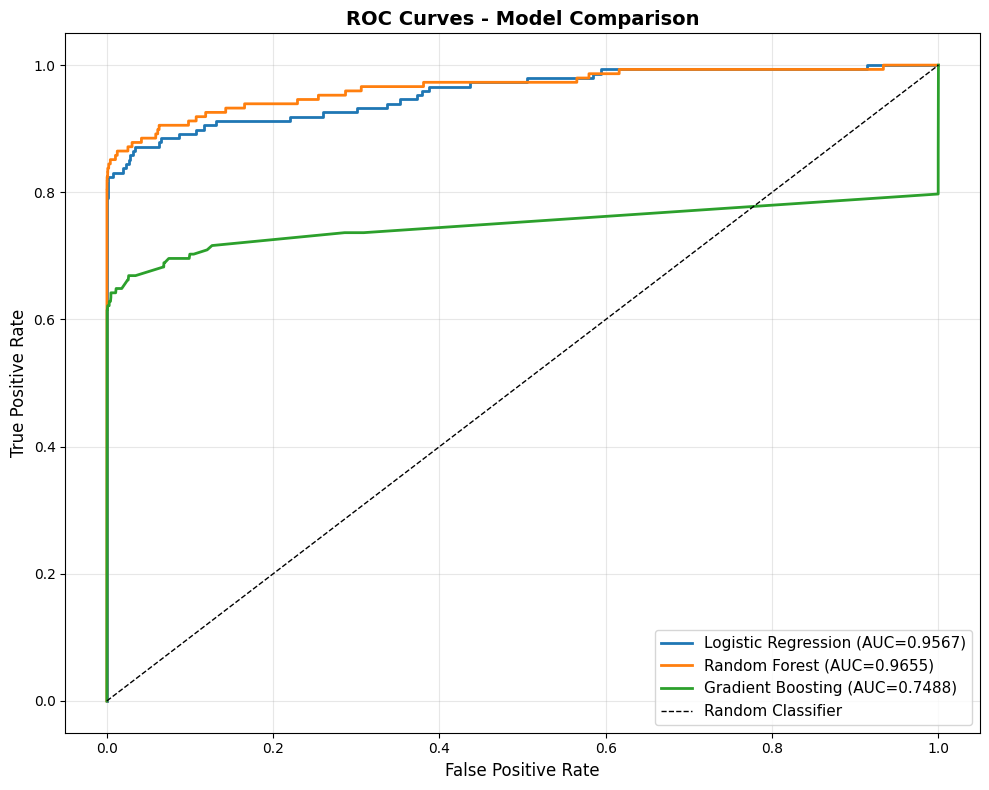

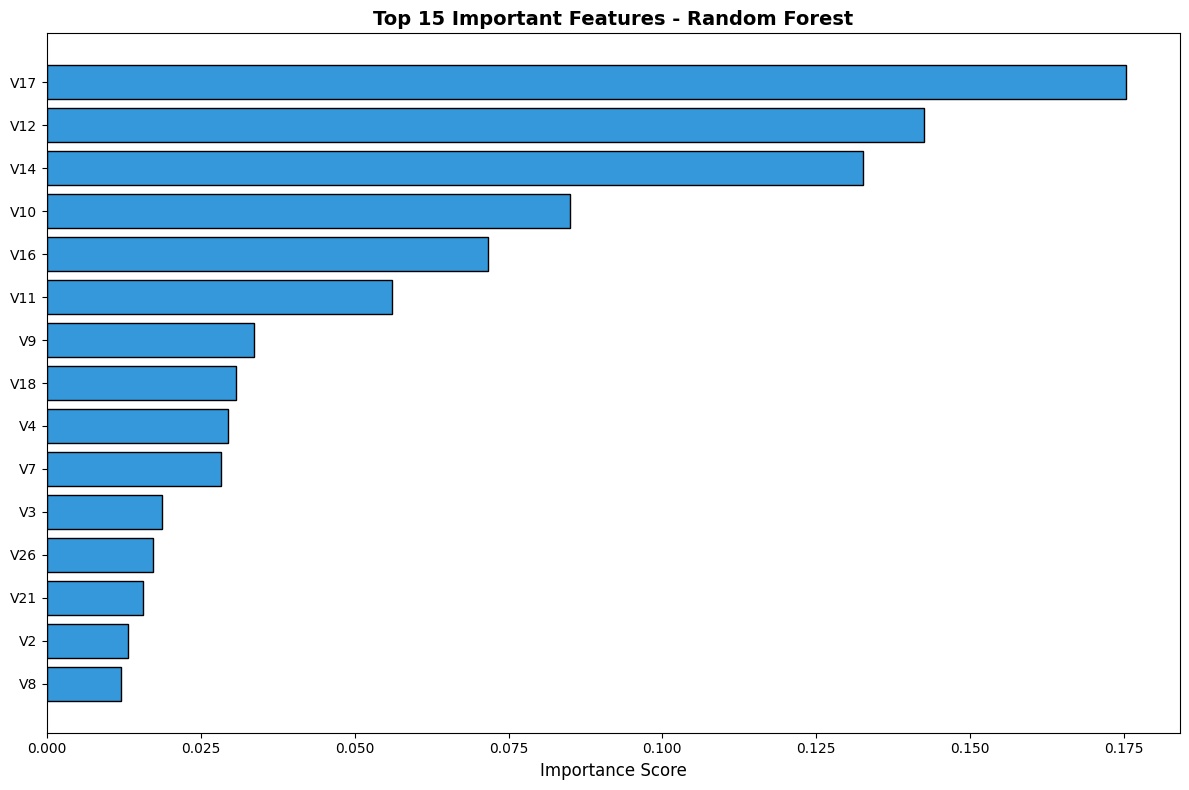

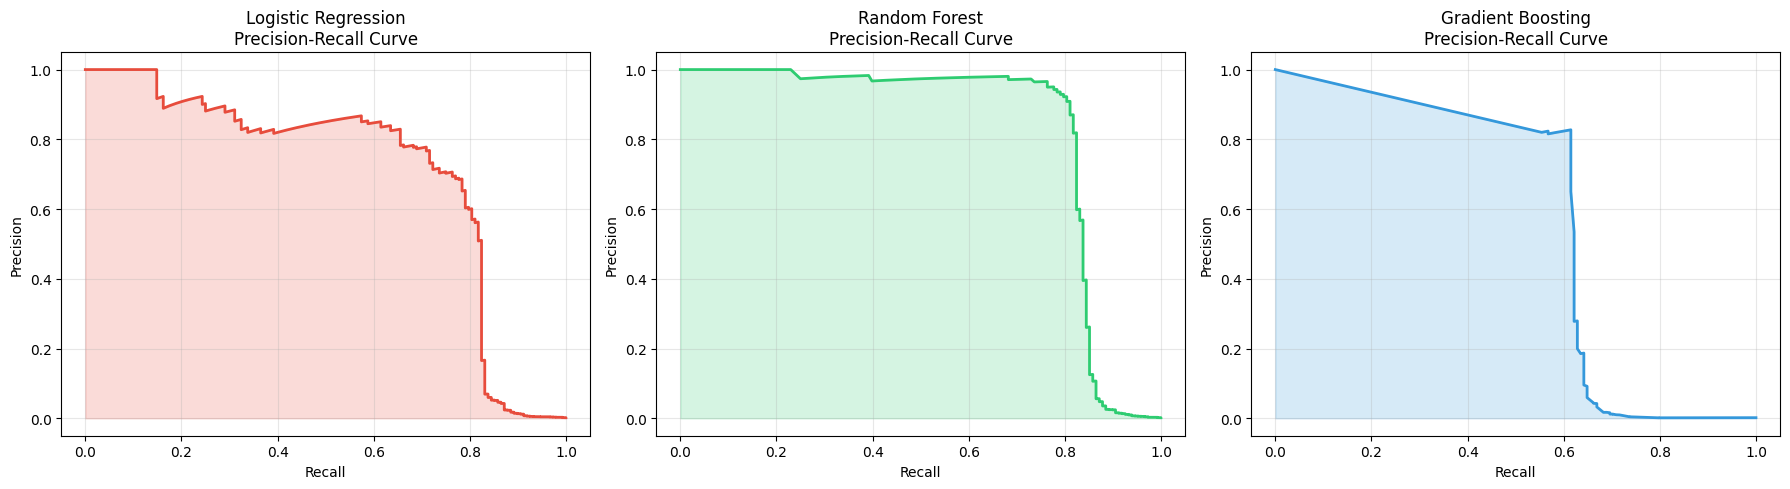

In [13]:
print("\n" + "="*60)
print("GENERATING VISUALIZATIONS")
print("="*60)
 
# Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
 
models_data = [
    (y_pred_lr, 'Logistic Regression'),
    (y_pred_rf, 'Random Forest'),
    (y_pred_gb, 'Gradient Boosting')
]
 
for idx, (y_pred, title) in enumerate(models_data):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False)
    axes[idx].set_title(f'{title}\nConfusion Matrix')
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')
    axes[idx].set_xticklabels(['Legitimate', 'Fraud'])
    axes[idx].set_yticklabels(['Legitimate', 'Fraud'])
 
plt.tight_layout()
plt.show()
 
# ROC Curves
plt.figure(figsize=(10, 8))
 
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_prob_rf)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_pred_prob_gb)
 
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={roc_auc_score(y_test, y_pred_prob_lr):.4f})', linewidth=2)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={roc_auc_score(y_test, y_pred_prob_rf):.4f})', linewidth=2)
plt.plot(fpr_gb, tpr_gb, label=f'Gradient Boosting (AUC={roc_auc_score(y_test, y_pred_prob_gb):.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
 
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - Model Comparison', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
 
# Feature Importance
fig, ax = plt.subplots(figsize=(12, 8))
top_features = feature_importance.head(15)
ax.barh(top_features['Feature'], top_features['Importance'], color='#3498db', edgecolor='black')
ax.set_xlabel('Importance Score', fontsize=12)
ax.set_title('Top 15 Important Features - Random Forest', fontsize=14, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()
 
# Precision-Recall Curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
 
precisions_lr, recalls_lr, _ = precision_recall_curve(y_test, y_pred_prob_lr)
precisions_rf, recalls_rf, _ = precision_recall_curve(y_test, y_pred_prob_rf)
precisions_gb, recalls_gb, _ = precision_recall_curve(y_test, y_pred_prob_gb)
 
axes[0].plot(recalls_lr, precisions_lr, linewidth=2, color='#e74c3c')
axes[0].fill_between(recalls_lr, precisions_lr, alpha=0.2, color='#e74c3c')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Logistic Regression\nPrecision-Recall Curve')
axes[0].grid(alpha=0.3)
 
axes[1].plot(recalls_rf, precisions_rf, linewidth=2, color='#2ecc71')
axes[1].fill_between(recalls_rf, precisions_rf, alpha=0.2, color='#2ecc71')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Random Forest\nPrecision-Recall Curve')
axes[1].grid(alpha=0.3)
 
axes[2].plot(recalls_gb, precisions_gb, linewidth=2, color='#3498db')
axes[2].fill_between(recalls_gb, precisions_gb, alpha=0.2, color='#3498db')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Gradient Boosting\nPrecision-Recall Curve')
axes[2].grid(alpha=0.3)
 
plt.tight_layout()
plt.show()

#### STEP 11: BEST MODEL ANALYSIS 

In [14]:
print("\n" + "="*60)
print("BEST MODEL ANALYSIS ")
print("="*60)
 
# Analyze false positives and false negatives
cm_gb = confusion_matrix(y_test, y_pred_gb)
tn, fp, fn, tp = cm_gb.ravel()
 
print(f"\nConfusion Matrix Breakdown:")
print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP): {tp}")
 
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
print(f"\nSensitivity (Recall): {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")
 


BEST MODEL ANALYSIS 

Confusion Matrix Breakdown:
True Negatives (TN): 85276
False Positives (FP): 19
False Negatives (FN): 57
True Positives (TP): 91

Sensitivity (Recall): 0.6149
Specificity: 0.9998


####  STEP 12: REAL-WORLD PREDICTIONS

In [15]:
print("\n" + "="*60)
print("SAMPLE PREDICTIONS ON TEST SET")
print("="*60)
 
# Get some random test samples
sample_indices = np.random.choice(len(X_test), 10, replace=False)
 
sample_predictions = pd.DataFrame({
    'Actual': y_test.iloc[sample_indices].values,
    'Predicted': y_pred_gb[sample_indices],
    'Fraud_Probability': y_pred_prob_gb[sample_indices]
})
 
sample_predictions['Actual_Label'] = sample_predictions['Actual'].map({0: 'Legitimate', 1: 'Fraud'})
sample_predictions['Predicted_Label'] = sample_predictions['Predicted'].map({0: 'Legitimate', 1: 'Fraud'})
 
print("\n")
print(sample_predictions[['Actual_Label', 'Predicted_Label', 'Fraud_Probability']].to_string(index=False))
 


SAMPLE PREDICTIONS ON TEST SET


Actual_Label Predicted_Label  Fraud_Probability
  Legitimate      Legitimate           0.000107
  Legitimate      Legitimate           0.000507
  Legitimate      Legitimate           0.000107
  Legitimate      Legitimate           0.000163
  Legitimate      Legitimate           0.000107
  Legitimate      Legitimate           0.000163
  Legitimate      Legitimate           0.000107
  Legitimate      Legitimate           0.000107
  Legitimate      Legitimate           0.000107
  Legitimate      Legitimate           0.000107
